# Two answers to where the rotor is

The drive's observer (injection + back-EMF, 50 kHz, `theta_hat`) and the
shaft sensor (A1335, link rate) - one rotor, measured two ways. This runs
the sensorless velocity loop while the sensor watches INDEPENDENTLY: the
cross-check the bench will run before the observer is trusted with
anything, and the handover a real application makes - position from the
sensor at standstill, speed from the observer once it is turning.

The Monte Carlo put the sensorless floor at a median 24-69 rpm across the
link sweep (`foc_montecarlo.ipynb`); the sensor is what will measure that
floor on hardware.

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial import Coaxial63100

SIMULATED = True                    # False at the bench
PORT = 'COM4'

BLUE, RED, GREY = '#1f4e79', '#c0392b', '#95a5a6'
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.15})

rig = Coaxial63100(port=PORT, simulated_device=SIMULATED,
                   power_afe=False).open()
rig.drive.source('model')           # the virtual rotor; 'adc' at the bench
rig.gates.arm(bypass_sto=True, ignore_interlock=True)
print(rig)

<Coaxial63100 Simulated SIMULATED>


## Spin sensorless, watch with the sensor

`watch` runs once per control pass. It logs the observer's speed and the
raw shaft angle; shaft SPEED is derived afterwards by differentiating the
unwrapped angle - the same arithmetic `sysid` uses.

The profile stays under 450 rpm ON PURPOSE: the link samples the shaft at
about 25 Hz, so Nyquist puts the honest witness ceiling near 700 rpm -
above it the unwrap invents turns and the 'sensor' becomes fiction.
Watching the observer at full speed needs the shaft angle inside DAQ
records, which is TODO 0's wire format.

In [2]:
log = []
t0 = time.perf_counter()
with rig.motion.velocity(amps=4.0, hz=2.0) as v:
    def peek(v):
        log.append((time.perf_counter() - t0, v.bus.w_ref, v.bus.w,
                    rig.angle.state()['degrees'], v.bus.iq_ref))
    v.rpm(450, seconds=3.0, watch=peek)
    v.rpm(150, seconds=2.0, watch=peek)
    v.stop(1.5)

t_s, w_ref, w_hat, shaft, iq = np.array(log).T
rpm_ref = w_ref * 60 / (2 * math.pi)
rpm_hat = w_hat * 60 / (2 * math.pi)
unwrapped = np.unwrap(shaft, period=360.0)
rpm_shaft = np.gradient(unwrapped, t_s) / 6.0   # deg/s -> rpm
print('%d passes over %.1f s' % (len(log), t_s[-1]))

125 passes over 5.2 s


disagreement: mean -0.0 rpm, sd 1.1 (differentiation noise included)


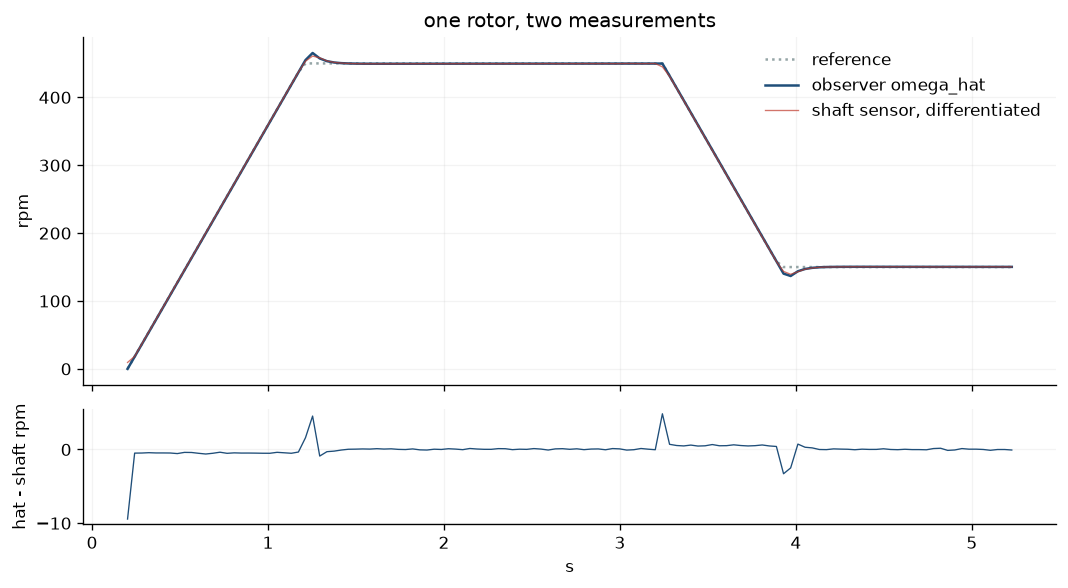

In [3]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(9, 5),
                       gridspec_kw={'height_ratios': [3, 1]})
ax[0].plot(t_s, rpm_ref, color=GREY, ls=':', label='reference')
ax[0].plot(t_s, rpm_hat, color=BLUE, label='observer omega_hat')
ax[0].plot(t_s, rpm_shaft, color=RED, lw=0.8, alpha=0.7,
           label='shaft sensor, differentiated')
ax[0].set(ylabel='rpm', title='one rotor, two measurements')
ax[0].legend(frameon=False)
ax[1].plot(t_s, rpm_hat - rpm_shaft, color=BLUE, lw=0.8)
ax[1].set(xlabel='s', ylabel='hat - shaft rpm')
fig.tight_layout()
err = rpm_hat - rpm_shaft
print('disagreement: mean %+.1f rpm, sd %.1f (differentiation noise '
      'included)' % (err.mean(), err.std()))

## What to make of the disagreement

The observer is the CONTROLLER's answer and the sensor is an independent
witness at maybe a hundredth of the bandwidth - the sd above is mostly
the differentiation of a quantised angle at link rate, not the observer.
What the bench cares about is the MEAN and where it grows: a bias says
scaling or pole count, growth at low rpm says the back-EMF floor - the
24-69 rpm the Monte Carlo predicts is exactly the region this plot will
either confirm or embarrass on hardware.